In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings

df = pd.read_csv('df_transacciones_limpio.csv').dropna()
df_sample = df.sample(n=5000, random_state=42)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

y = df_sample['industria']

base_feature = ['nombre_prod']
features_extra = ['cantidad_comp_15', 'duracion_carga_seg', 'dia_de_semana']

print("--- DIAGNÓSTICO INCREMENTAL DE VARIABLES ---")

for i in range(len(features_extra) + 1):
    current_features = base_feature + features_extra[:i]

    X_temp = df_sample[current_features].copy()

    if 'dia_de_semana' in X_temp.columns:
        X_temp['dia_de_semana'] = X_temp['dia_de_semana'].astype(str)

    X_encoded_temp = pd.get_dummies(X_temp, drop_first=True).astype(int)

    X_tr, X_te, y_tr, y_te = train_test_split(
        X_encoded_temp, y, test_size=0.3, random_state=42, stratify=y
    )

    clf_diag = RandomForestClassifier(random_state=42, n_estimators=50)
    clf_diag.fit(X_tr, y_tr)

    acc = accuracy_score(y_te, clf_diag.predict(X_te))

    print(f"Precisión usando {current_features}: {acc:.4f}")

--- DIAGNÓSTICO INCREMENTAL DE VARIABLES ---
Precisión usando ['nombre_prod']: 0.7533
Precisión usando ['nombre_prod', 'cantidad_comp_15']: 0.7273
Precisión usando ['nombre_prod', 'cantidad_comp_15', 'duracion_carga_seg']: 0.7273
Precisión usando ['nombre_prod', 'cantidad_comp_15', 'duracion_carga_seg', 'dia_de_semana']: 0.7293


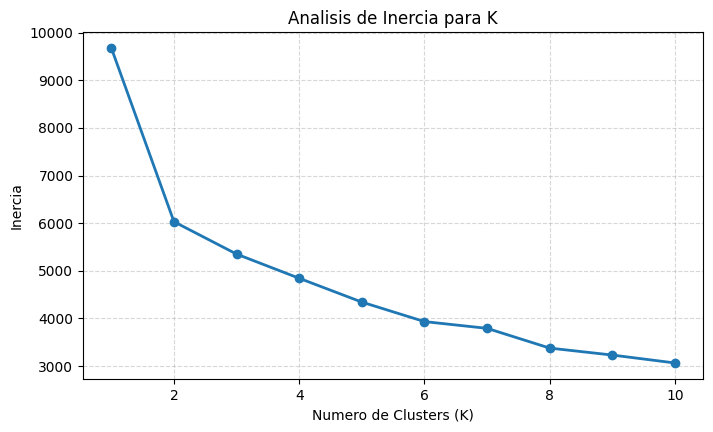

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings

X_continua = df_sample[['cantidad']]
X_categorica = df_sample[['nombre_prod']]

X_dummies = pd.get_dummies(X_categorica, drop_first=True).astype(int)

scaler = StandardScaler()
X_continua_scaled = scaler.fit_transform(X_continua)

X_real_scaled = pd.concat([
    pd.DataFrame(X_continua_scaled, columns=['cantidad_scaled'], index=X_dummies.index),
    X_dummies
], axis=1)

inercia = []
for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_real_scaled)
    inercia.append(model.inertia_)

plt.figure(figsize=(8, 4.5))
plt.plot(range(1, 11), inercia, marker='o', linewidth=2)
plt.xlabel('Numero de Clusters (K)')
plt.ylabel('Inercia')
plt.title('Analisis de Inercia para K')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()